# Оценка sentence embeddings на русскоязычных NLI-парах

Тема НИР: «Оценка способности русскоязычных sentence embeddings различать семантическую близость и логическое противоречие в парах предложений».

## Цель эксперимента

Оценить, насколько cosine similarity между русскоязычными sentence embeddings позволяет различать семантически близкие, нейтральные и логически противоречивые пары предложений.

In [1]:
%cd /content
!rm -rf /content/nir-sentence-embeddings

/content


In [2]:
# Ячейка для запуска в Google Colab.
# Если репозиторий уже склонирован и зависимости установлены, эту ячейку можно пропустить.
# В Colab не устанавливаем пакет jupyter из requirements.txt, чтобы не конфликтовать с google-colab.
%cd /content
!git clone https://github.com/yaroslav2308/nir-sentence-embeddings.git
%cd nir-sentence-embeddings
!grep -v "^jupyter$" requirements.txt > /tmp/requirements-colab.txt
!pip install -r /tmp/requirements-colab.txt

/content
Cloning into 'nir-sentence-embeddings'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 43 (delta 15), reused 36 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 83.25 KiB | 1.14 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/nir-sentence-embeddings


In [3]:
import sys
from pathlib import Path

repo_path = Path.cwd()
if str(repo_path) not in sys.path:
    sys.path.append(str(repo_path))

# Альтернативно в Colab после clone можно явно указать путь:
# sys.path.append("/content/nir-sentence-embeddings")

In [4]:
import pandas as pd
from matplotlib import pyplot as plt

from src.data import add_text_stats, load_xnli_ru, sample_balanced
from src.evaluation import (
    aggregate_by_label,
    compute_auc_entailment_vs_contradiction,
    compute_delta_entailment_contradiction,
    get_high_similarity_contradictions,
)
from src.models import compute_sentence_transformer_similarity, compute_tfidf_similarity
from src.visualization import plot_similarity_by_label

In [5]:
df = load_xnli_ru(split="validation")
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,premise,hypothesis,label
0,"И он сказал: Мама, я дома.","Он позвал маму, как только вышел из школьного ...",neutral
1,"И он сказал: Мама, я дома.",Он не произнес ни слова.,contradiction
2,"И он сказал: Мама, я дома.","Он сказал матери, что уже добрался домой.",entailment
3,"Я не знал, что мне предстояло сделать и все та...","Я раньше не был в Вашингтоне, поэтому, получив...",neutral
4,"Я не знал, что мне предстояло сделать и все та...","Я точно знал, что мне нужно сделать, когда вхо...",contradiction


In [6]:
sample_df = sample_balanced(df, n_per_class=300, random_state=42)
sample_df = add_text_stats(sample_df)
sample_df["label"].value_counts()

,count
label,
contradiction,300
neutral,300
entailment,300


In [7]:
sample_df["tfidf_similarity"] = compute_tfidf_similarity(sample_df)
sample_df[["premise", "hypothesis", "label", "tfidf_similarity"]].head()

,premise,hypothesis,label,tfidf_similarity
0,"Уважаемый Доктор Спунер, любезный человек с с...",Доктор Спунер покинул Нью Колледж после двадца...,contradiction,0.119640
1,"последний контракт, который был выигран Virgin...",Контракты выявили немало спорных моментов у юр...,neutral,0.000000
2,"Рациональные ожидания выросли, частично, из по...",Никого не интересовал реальный трейдинг на фон...,contradiction,0.018920
3,Вклад работодателя в программы социального стр...,Работодатели вкладывают в социальные программы.,entailment,0.145792
4,"Моя бабушка родилась в 1910 году, она была мал...",Моя бабушка родилась в 1899 году.,contradiction,0.560387


In [10]:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
sample_df["st_similarity"] = compute_sentence_transformer_similarity(
    sample_df,
    model_name=model_name,
    batch_size=32,
)
sample_df[["premise", "hypothesis", "label", "st_similarity"]].head()

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

,premise,hypothesis,label,st_similarity
0,"Уважаемый Доктор Спунер, любезный человек с с...",Доктор Спунер покинул Нью Колледж после двадца...,contradiction,0.587693
1,"последний контракт, который был выигран Virgin...",Контракты выявили немало спорных моментов у юр...,neutral,0.400501
2,"Рациональные ожидания выросли, частично, из по...",Никого не интересовал реальный трейдинг на фон...,contradiction,0.380260
3,Вклад работодателя в программы социального стр...,Работодатели вкладывают в социальные программы.,entailment,0.797224
4,"Моя бабушка родилась в 1910 году, она была мал...",Моя бабушка родилась в 1899 году.,contradiction,0.720771


In [8]:
aggregate_by_label(sample_df, "tfidf_similarity")

,label,count,mean,std,median,min,max
0,contradiction,300,0.113631,0.122269,0.086313,0.0,0.562298
1,entailment,300,0.171422,0.162506,0.138331,0.0,0.832679
2,neutral,300,0.103167,0.119382,0.073334,0.0,0.589089


In [11]:
aggregate_by_label(sample_df, "st_similarity")

,label,count,mean,std,median,min,max
0,contradiction,300,0.431168,0.186125,0.433848,-0.016202,0.907451
1,entailment,300,0.652786,0.154003,0.667982,0.214873,0.973722
2,neutral,300,0.516406,0.184037,0.521441,-0.002648,0.919979


In [12]:
for score_column in ["tfidf_similarity", "st_similarity"]:
    delta = compute_delta_entailment_contradiction(sample_df, score_column)
    auc = compute_auc_entailment_vs_contradiction(sample_df, score_column)
    print(f"{score_column}: delta={delta:.4f}, ROC-AUC={auc:.4f}")

tfidf_similarity: delta=0.0578, ROC-AUC=0.6037
st_similarity: delta=0.2216, ROC-AUC=0.8176


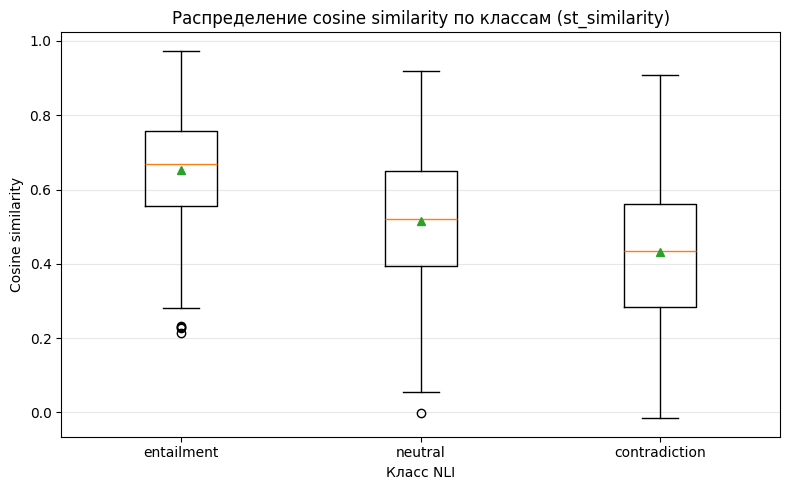

In [13]:
fig = plot_similarity_by_label(sample_df, "st_similarity")
plt.show()

In [14]:
columns = ["premise", "hypothesis", "label", "st_similarity", "lexical_overlap"]
get_high_similarity_contradictions(sample_df, "st_similarity", top_n=10)[columns]

,premise,hypothesis,label,st_similarity,lexical_overlap
0,Джереми Питт ответил на смех проклятием.,Джереми Пит ответил на смех ухмылкой и ударом ...,contradiction,0.907451,0.285714
1,Сегодня эти германизмы даже в США не остаются.,Эти германизмы больше не используются в Соедин...,contradiction,0.903214,0.333333
2,"Предполагается, что уровень загрязнения воздух...","Независимо от степени загрязнения воздуха, оно...",contradiction,0.838970,0.173913
3,"Кроме того, немногие почтовые службы платят св...",Почтовые работники в США зарабатывают гораздо ...,contradiction,0.838143,0.120000
4,В качестве предположительного адреса пребывани...,Михдхар чудесно провел время в отеле Marriott ...,contradiction,0.833413,0.285714
5,"Когда гражданское общество затыкает себе уши,...",Сумасшедшие идеи набирают популярность в гражд...,contradiction,0.832053,0.190476
6,"Главным, однако, является то, что в мире совсе...",По всему миру можно найти много Милошевичей.,contradiction,0.796689,0.047619
7,Соединенные Штаты не были основным источником ...,США определенно не поддерживали Аль-Каиду день...,contradiction,0.795764,0.115385
8,Юго-восточный сектор ПВО был проинформирован о...,Юго-восточный сектор ПВО получил сообщение о п...,contradiction,0.790387,0.388889
9,"Но именно от Старого Волка будет зависеть, зах...",Он хочет встретиться с тобой по поводу Старого...,contradiction,0.788388,0.142857


## Черновик интерпретации результатов

После запуска нужно сравнить распределения similarity для `entailment`, `neutral` и `contradiction`. Если contradiction-пары часто получают высокую similarity, это может означать, что embedding-модель хорошо улавливает тематическую и лексическую близость, но хуже отражает логическое противоречие, особенно при отрицании или замене ключевого признака на противоположный.

Особое внимание стоит уделить таблице contradiction-пар с высокой cosine similarity: такие примеры помогут описать типичные ошибки модели и ограничения cosine similarity как самостоятельного критерия логического отношения между предложениями.

## Контрольный эксперимент с NLI-моделью

В этом блоке используется специализированная NLI-модель `cointegrated/rubert-base-cased-nli-threeway`. В отличие от sentence embeddings, которые кодируют предложения независимо и затем сравниваются через cosine similarity, NLI-модель получает пару `premise + hypothesis` и напрямую предсказывает отношение `entailment`, `neutral` или `contradiction`.

In [15]:
import random
from pathlib import Path

import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

STANDARD_LABELS = ["entailment", "neutral", "contradiction"]
NLI_MODEL_NAME = "cointegrated/rubert-base-cased-nli-threeway"
NLI_BATCH_SIZE = 16


def normalize_nli_label(label: object) -> str:
    """Normalize model label names to entailment, neutral, contradiction."""
    text = str(label).lower().strip()
    text = text.replace("-", "_").replace(" ", "_")

    aliases = {
        "entailment": "entailment",
        "entails": "entailment",
        "entailed": "entailment",
        "neutral": "neutral",
        "neither": "neutral",
        "contradiction": "contradiction",
        "contradictory": "contradiction",
        "contradicts": "contradiction",
    }
    if text in aliases:
        return aliases[text]
    if "entail" in text:
        return "entailment"
    if "neutral" in text or "neither" in text:
        return "neutral"
    if "contrad" in text or "contr" in text:
        return "contradiction"

    raise ValueError(f"Не удалось привести label модели к стандартному классу: {label!r}")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство для NLI inference: {device}")

tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_NAME)
nli_model.to(device)
nli_model.eval()

id2label = {int(idx): label for idx, label in nli_model.config.id2label.items()}
nli_label_by_id = {idx: normalize_nli_label(label) for idx, label in sorted(id2label.items())}
print("id2label модели:", id2label)
print("Нормализованные label:", nli_label_by_id)

if set(nli_label_by_id.values()) != set(STANDARD_LABELS):
    raise ValueError(f"Модель должна иметь классы {STANDARD_LABELS}, получено: {nli_label_by_id}")

Устройство для NLI inference: cpu


tokenizer_config.json:   0%|          | 0.00/545 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

id2label модели: {0: 'entailment', 1: 'contradiction', 2: 'neutral'}
Нормализованные label: {0: 'entailment', 1: 'contradiction', 2: 'neutral'}


In [16]:
def predict_nli_batchwise(df: pd.DataFrame, batch_size: int = 16) -> pd.DataFrame:
    """Run batched NLI inference and return probabilities and predicted labels."""
    probabilities_by_label = {label: [] for label in STANDARD_LABELS}
    predicted_labels = []

    for start in tqdm(range(0, len(df), batch_size), desc="NLI inference"):
        batch = df.iloc[start : start + batch_size]
        premises = batch["premise"].fillna("").astype(str).tolist()
        hypotheses = batch["hypothesis"].fillna("").astype(str).tolist()

        encoded = tokenizer(
            premises,
            hypotheses,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt",
        )
        encoded = {name: tensor.to(device) for name, tensor in encoded.items()}

        with torch.inference_mode():
            logits = nli_model(**encoded).logits
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()

        pred_ids = probs.argmax(axis=1)
        for row_probs, pred_id in zip(probs, pred_ids):
            for class_id, probability in enumerate(row_probs):
                label = nli_label_by_id[class_id]
                probabilities_by_label[label].append(float(probability))
            predicted_labels.append(nli_label_by_id[int(pred_id)])

    result = pd.DataFrame(
        {
            "nli_p_entailment": probabilities_by_label["entailment"],
            "nli_p_neutral": probabilities_by_label["neutral"],
            "nli_p_contradiction": probabilities_by_label["contradiction"],
            "nli_pred_label": predicted_labels,
        },
        index=df.index,
    )
    return result


nli_predictions = predict_nli_batchwise(sample_df, batch_size=NLI_BATCH_SIZE)
for column in nli_predictions.columns:
    sample_df[column] = nli_predictions[column]

sample_df["nli_correct"] = sample_df["label"] == sample_df["nli_pred_label"]
sample_df["nli_score"] = sample_df["nli_p_entailment"] - sample_df["nli_p_contradiction"]

sample_df[
    [
        "premise",
        "hypothesis",
        "label",
        "nli_pred_label",
        "nli_correct",
        "nli_p_entailment",
        "nli_p_neutral",
        "nli_p_contradiction",
    ]
].head()

NLI inference:   0%|          | 0/57 [00:00<?, ?it/s]

,premise,hypothesis,label,nli_pred_label,nli_correct,nli_p_entailment,nli_p_neutral,nli_p_contradiction
0,"Уважаемый Доктор Спунер, любезный человек с с...",Доктор Спунер покинул Нью Колледж после двадца...,contradiction,neutral,False,0.018636,0.785466,0.195899
1,"последний контракт, который был выигран Virgin...",Контракты выявили немало спорных моментов у юр...,neutral,neutral,True,0.002190,0.995536,0.002274
2,"Рациональные ожидания выросли, частично, из по...",Никого не интересовал реальный трейдинг на фон...,contradiction,contradiction,True,0.000400,0.003238,0.996362
3,Вклад работодателя в программы социального стр...,Работодатели вкладывают в социальные программы.,entailment,entailment,True,0.953052,0.036953,0.009995
4,"Моя бабушка родилась в 1910 году, она была мал...",Моя бабушка родилась в 1899 году.,contradiction,contradiction,True,0.004949,0.004301,0.990750


In [18]:
nli_accuracy = accuracy_score(sample_df["label"], sample_df["nli_pred_label"])
nli_macro_f1 = f1_score(
    sample_df["label"],
    sample_df["nli_pred_label"],
    labels=STANDARD_LABELS,
    average="macro",
    zero_division=0,
)

print(f"NLI Accuracy: {nli_accuracy:.4f}")
print(f"NLI Macro-F1: {nli_macro_f1:.4f}")

report_dict = classification_report(
    sample_df["label"],
    sample_df["nli_pred_label"],
    labels=STANDARD_LABELS,
    output_dict=True,
    zero_division=0,
)
nli_report_df = pd.DataFrame(report_dict).T
nli_report_df.to_csv(OUTPUT_DIR / "nli_classification_report.csv")

cm = confusion_matrix(sample_df["label"], sample_df["nli_pred_label"], labels=STANDARD_LABELS)
nli_confusion_df = pd.DataFrame(
    cm,
    index=[f"true_{label}" for label in STANDARD_LABELS],
    columns=[f"pred_{label}" for label in STANDARD_LABELS],
)
nli_confusion_df.to_csv(OUTPUT_DIR / "nli_confusion_matrix.csv")

display(nli_report_df)
display(nli_confusion_df)

NLI Accuracy: 0.7611
NLI Macro-F1: 0.7615


,precision,recall,f1-score,support
entailment,0.854167,0.683333,0.759259,300.000000
neutral,0.686610,0.803333,0.740399,300.000000
contradiction,0.773463,0.796667,0.784893,300.000000
accuracy,0.761111,0.761111,0.761111,0.761111
macro avg,0.771413,0.761111,0.761517,900.000000
weighted avg,0.771413,0.761111,0.761517,900.000000


,pred_entailment,pred_neutral,pred_contradiction
true_entailment,205,60,35
true_neutral,24,241,35
true_contradiction,11,50,239


In [19]:
roc_comparison = pd.DataFrame(
    [
        {
            "method": "TF-IDF",
            "score": "tfidf_similarity",
            "roc_auc_entailment_vs_contradiction": compute_auc_entailment_vs_contradiction(
                sample_df, "tfidf_similarity"
            ),
        },
        {
            "method": "SentenceTransformer",
            "score": "st_similarity",
            "roc_auc_entailment_vs_contradiction": compute_auc_entailment_vs_contradiction(
                sample_df, "st_similarity"
            ),
        },
        {
            "method": "NLI RuBERT",
            "score": "p_entailment - p_contradiction",
            "roc_auc_entailment_vs_contradiction": compute_auc_entailment_vs_contradiction(
                sample_df, "nli_score"
            ),
        },
    ]
)
roc_comparison.to_csv(OUTPUT_DIR / "roc_comparison.csv", index=False)
roc_comparison

,method,score,roc_auc_entailment_vs_contradiction
0,TF-IDF,tfidf_similarity,0.603672
1,SentenceTransformer,st_similarity,0.817589
2,NLI RuBERT,p_entailment - p_contradiction,0.943544


In [20]:
analysis_columns = [
    "premise",
    "hypothesis",
    "label",
    "st_similarity",
    "lexical_overlap",
    "nli_p_entailment",
    "nli_p_neutral",
    "nli_p_contradiction",
    "nli_pred_label",
    "nli_correct",
]

high_st_contradictions = sample_df[
    (sample_df["label"] == "contradiction") & (sample_df["st_similarity"] >= 0.75)
].copy()

st_high_nli_correct_contradictions = high_st_contradictions[
    high_st_contradictions["nli_pred_label"] == "contradiction"
].sort_values("st_similarity", ascending=False)

both_failed_high_similarity_contradictions = high_st_contradictions[
    high_st_contradictions["nli_pred_label"] != "contradiction"
].sort_values("st_similarity", ascending=False)

high_st_nli_summary = (
    high_st_contradictions["nli_pred_label"]
    .value_counts()
    .rename_axis("nli_pred_label")
    .reset_index(name="count")
)

st_high_nli_correct_contradictions[analysis_columns].to_csv(
    OUTPUT_DIR / "st_high_nli_correct_contradictions.csv",
    index=False,
)
both_failed_high_similarity_contradictions[analysis_columns].to_csv(
    OUTPUT_DIR / "both_failed_high_similarity_contradictions.csv",
    index=False,
)
high_st_nli_summary.to_csv(
    OUTPUT_DIR / "high_similarity_contradictions_nli_pred_summary.csv",
    index=False,
)

print("Сводка NLI-предсказаний для contradiction-пар с st_similarity >= 0.75:")
display(high_st_nli_summary)

print("ST similarity высокая, NLI правильно определил contradiction:")
display(st_high_nli_correct_contradictions[analysis_columns].head(10))

print("ST similarity высокая, NLI тоже ошибся:")
display(both_failed_high_similarity_contradictions[analysis_columns].head(10))

Сводка NLI-предсказаний для contradiction-пар с st_similarity >= 0.75:


,nli_pred_label,count
0,contradiction,7
1,entailment,6
2,neutral,1


ST similarity высокая, NLI правильно определил contradiction:


,premise,hypothesis,label,st_similarity,lexical_overlap,nli_p_entailment,nli_p_neutral,nli_p_contradiction,nli_pred_label,nli_correct
611,Джереми Питт ответил на смех проклятием.,Джереми Пит ответил на смех ухмылкой и ударом ...,contradiction,0.907451,0.285714,0.000572,0.010979,0.988449,contradiction,True
500,"Кроме того, немногие почтовые службы платят св...",Почтовые работники в США зарабатывают гораздо ...,contradiction,0.838143,0.120000,0.058828,0.268459,0.672713,contradiction,True
477,"Главным, однако, является то, что в мире совсе...",По всему миру можно найти много Милошевичей.,contradiction,0.796689,0.047619,0.010190,0.009876,0.979934,contradiction,True
693,Соединенные Штаты не были основным источником ...,США определенно не поддерживали Аль-Каиду день...,contradiction,0.795764,0.115385,0.067701,0.081849,0.850450,contradiction,True
32,Юго-восточный сектор ПВО был проинформирован о...,Юго-восточный сектор ПВО получил сообщение о п...,contradiction,0.790387,0.388889,0.190836,0.024548,0.784616,contradiction,True
140,"Но именно от Старого Волка будет зависеть, зах...",Он хочет встретиться с тобой по поводу Старого...,contradiction,0.788388,0.142857,0.010093,0.403724,0.586183,contradiction,True
122,Самая распространенная причина в раннем детств...,Отит среднего уха встречается редко в дошкольн...,contradiction,0.763972,0.200000,0.089979,0.278032,0.631989,contradiction,True


ST similarity высокая, NLI тоже ошибся:


,premise,hypothesis,label,st_similarity,lexical_overlap,nli_p_entailment,nli_p_neutral,nli_p_contradiction,nli_pred_label,nli_correct
840,Сегодня эти германизмы даже в США не остаются.,Эти германизмы больше не используются в Соедин...,contradiction,0.903214,0.333333,0.968069,0.024963,0.006967,entailment,False
791,"Предполагается, что уровень загрязнения воздух...","Независимо от степени загрязнения воздуха, оно...",contradiction,0.838970,0.173913,0.591649,0.119141,0.289210,entailment,False
787,В качестве предположительного адреса пребывани...,Михдхар чудесно провел время в отеле Marriott ...,contradiction,0.833413,0.285714,0.016942,0.731502,0.251555,neutral,False
457,"Когда гражданское общество затыкает себе уши,...",Сумасшедшие идеи набирают популярность в гражд...,contradiction,0.832053,0.190476,0.881959,0.079322,0.038719,entailment,False
890,"Ну вот таким образом, эм, я остался пристёгнут.",Именно так я и был отцеплен.,contradiction,0.781535,0.076923,0.917879,0.048097,0.034023,entailment,False
256,"Было ясно, что главной структурой реагирования...",Пожарный департамент Нью-Йорка не нес единолич...,contradiction,0.760992,0.078947,0.677944,0.242851,0.079204,entailment,False
765,Рост статуса и влияния нашей юридической школы...,Наша юридическая школа работает за счет частно...,contradiction,0.760193,0.000000,0.945326,0.035966,0.018709,entailment,False


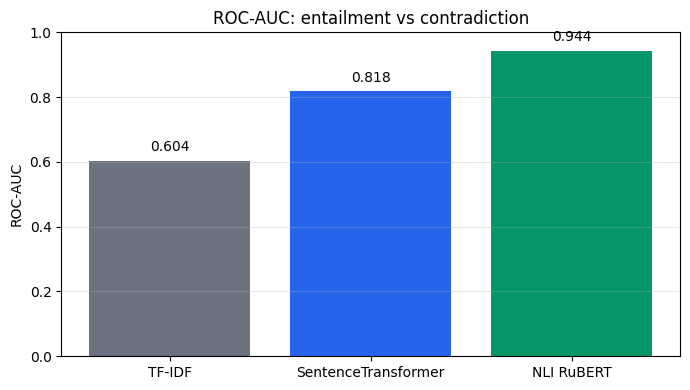

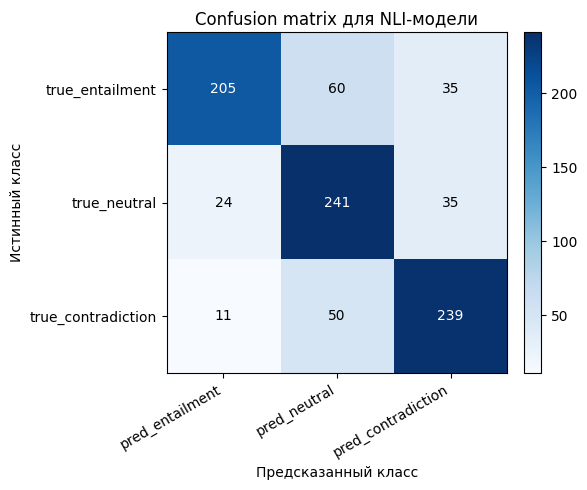

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    roc_comparison["method"],
    roc_comparison["roc_auc_entailment_vs_contradiction"],
    color=["#6B7280", "#2563EB", "#059669"],
)
ax.set_title("ROC-AUC: entailment vs contradiction")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.0, 1.0)
ax.grid(axis="y", alpha=0.3)
for index, value in enumerate(roc_comparison["roc_auc_entailment_vs_contradiction"]):
    ax.text(index, value + 0.02, f"{value:.3f}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "roc_auc_comparison.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(nli_confusion_df.values, cmap="Blues")
ax.set_title("Confusion matrix для NLI-модели")
ax.set_xlabel("Предсказанный класс")
ax.set_ylabel("Истинный класс")
ax.set_xticks(range(len(STANDARD_LABELS)))
ax.set_yticks(range(len(STANDARD_LABELS)))
ax.set_xticklabels([f"pred_{label}" for label in STANDARD_LABELS], rotation=30, ha="right")
ax.set_yticklabels([f"true_{label}" for label in STANDARD_LABELS])

threshold = nli_confusion_df.values.max() / 2
for row in range(nli_confusion_df.shape[0]):
    for col in range(nli_confusion_df.shape[1]):
        value = nli_confusion_df.iloc[row, col]
        text_color = "white" if value > threshold else "black"
        ax.text(col, row, str(value), ha="center", va="center", color=text_color)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "nli_confusion_matrix.png", dpi=150)
plt.show()

In [22]:
sample_df.to_csv(OUTPUT_DIR / "results_with_nli.csv", index=False)

print("Сохраненные файлы в outputs/:")
for output_path in sorted(OUTPUT_DIR.glob("*")):
    if output_path.is_file():
        print(output_path)

Сохраненные файлы в outputs/:
outputs/.gitkeep
outputs/both_failed_high_similarity_contradictions.csv
outputs/high_similarity_contradictions_nli_pred_summary.csv
outputs/nli_classification_report.csv
outputs/nli_confusion_matrix.csv
outputs/nli_confusion_matrix.png
outputs/results_with_nli.csv
outputs/roc_auc_comparison.png
outputs/roc_comparison.csv
outputs/st_high_nli_correct_contradictions.csv


## Промежуточные выводы после добавления NLI

SentenceTransformer сравнивает предложения независимо: сначала строятся embeddings для `premise` и `hypothesis`, затем считается cosine similarity. Такая оценка хорошо отражает общую семантическую или тематическую близость, но сама по себе не моделирует логическое отношение между предложениями.

NLI-модель анализирует пару предложений совместно и напрямую решает задачу классификации `entailment` / `neutral` / `contradiction`. Поэтому она используется как контрольный пример специализированного подхода к выявлению логического следования и противоречия.

Если NLI показывает более высокий ROC-AUC и лучше распознает contradiction-пары с высокой sentence embedding similarity, это подтверждает ограничение cosine similarity: высокая близость embeddings не гарантирует отсутствие логического противоречия.

В итоговом отчете по НИР этот блок можно использовать как аргумент, что sentence embeddings подходят для оценки общей семантической и тематической близости, но для задач выявления противоречий их желательно дополнять NLI-моделями.